PART 1

In [44]:
import numpy as np
import matplotlib.pyplot as plt

In [45]:
rng = np.random.default_rng(42)
N = 10000

mu1 = np.array([0.0, 0.0])
mu2 = np.array([4.0, 4.0])
mu3 = np.array([0.0, 6.0])

# Case 1 sigma^2 I, same for all classes
Sigma1 = np.array([[2.0, 0.0], [0.0, 2.0]])
Sigma2 = np.array([[2.0, 0.0], [0.0, 2.0]])
Sigma3 = np.array([[2.0, 0.0], [0.0, 2.0]])


In [46]:
def gaussian_2d(mu, Sigma, n, rng):
    S11 = Sigma[0, 0]
    S12 = Sigma[0, 1]
    S22 = Sigma[1, 1]

    x1 = gaussian(mu[0], np.sqrt(S11), n, rng)

    z = gaussian(0, 1, n, rng)
    cond_mean = mu[1] + (S12 / S11) * (x1 - mu[0])
    cond_var = S22 - S12 ** 2 / S11
    x2 = cond_mean + np.sqrt(cond_var) * z

    return np.column_stack((x1, x2))


In [47]:
def gaussian(mu, sigma, n, rng):
    return rng.normal(mu, sigma, n)


In [48]:
X1 = gaussian_2d(mu1, Sigma1, N, rng)
X2 = gaussian_2d(mu2, Sigma2, N, rng)
X3 = gaussian_2d(mu3, Sigma3, N, rng)

print(X1.shape, X2.shape, X3.shape)

(10000, 2) (10000, 2) (10000, 2)


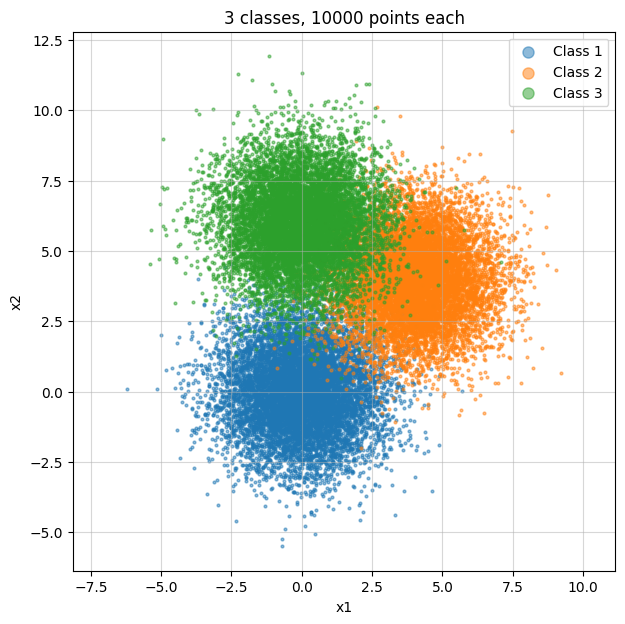

In [49]:
plt.figure(figsize=(7, 7))
plt.scatter(X1[:, 0], X1[:, 1], s=4, alpha=0.5, label="Class 1")
plt.scatter(X2[:, 0], X2[:, 1], s=4, alpha=0.5, label="Class 2")
plt.scatter(X3[:, 0], X3[:, 1], s=4, alpha=0.5, label="Class 3")
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("3 classes, 10000 points each")
plt.axis("equal"); plt.grid(alpha=0.5); plt.legend(markerscale=4)
plt.show()

In [50]:
# Three covariance types

Sigma_iso  = np.array([[3.0, 0.0], [0.0, 3.0]])
Sigma_diag = np.array([[6.0, 0.0], [0.0, 4.0]])
Sigma_full = np.array([[5.0, 1.5], [1.5, 2.0]])

# sigma^2 I, same for all 3 classes
A1 = gaussian_2d(mu1, Sigma_iso, N, rng)
A2 = gaussian_2d(mu2, Sigma_iso, N, rng)
A3 = gaussian_2d(mu3, Sigma_iso, N, rng)

# diagonal, same for all 3 classes
B1 = gaussian_2d(mu1, Sigma_diag, N, rng)
B2 = gaussian_2d(mu2, Sigma_diag, N, rng)
B3 = gaussian_2d(mu3, Sigma_diag, N, rng)

# full, same for all 3 classes
C1 = gaussian_2d(mu1, Sigma_full, N, rng)
C2 = gaussian_2d(mu2, Sigma_full, N, rng)
C3 = gaussian_2d(mu3, Sigma_full, N, rng)


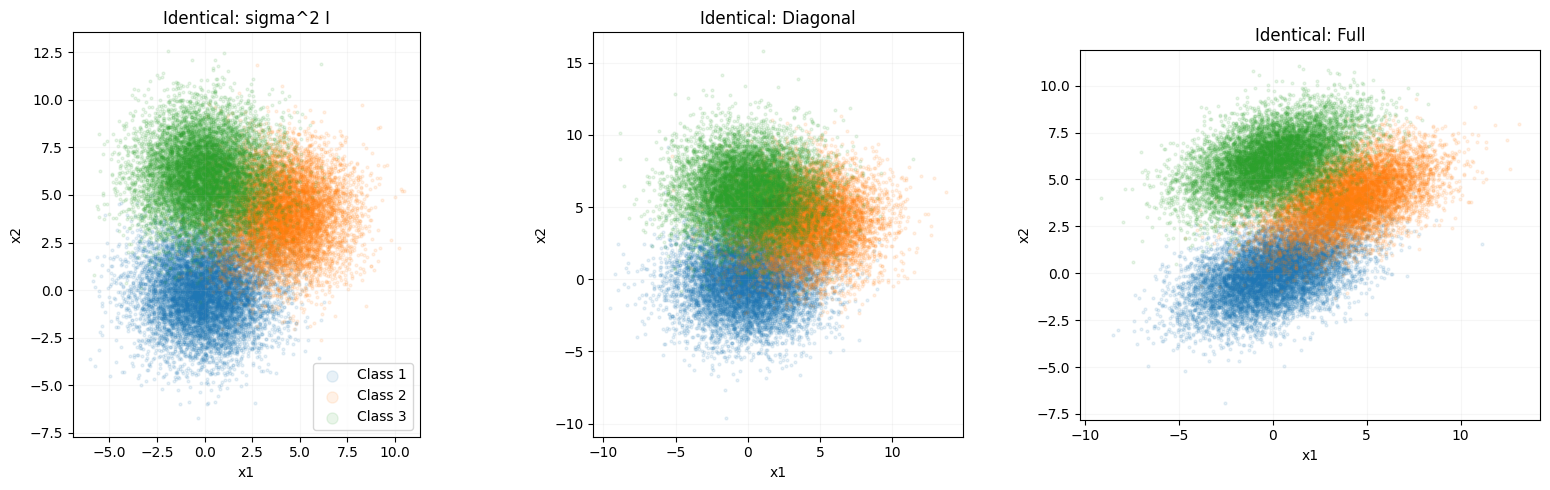

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sets = [("sigma^2 I", A1, A2, A3),
        ("Diagonal",  B1, B2, B3),
        ("Full",      C1, C2, C3)]

for ax, (title, P1, P2, P3) in zip(axes, sets):
    ax.scatter(P1[:, 0], P1[:, 1], s=4, alpha=0.1, label="Class 1")
    ax.scatter(P2[:, 0], P2[:, 1], s=4, alpha=0.1, label="Class 2")
    ax.scatter(P3[:, 0], P3[:, 1], s=4, alpha=0.1, label="Class 3")
    ax.set_title(f"Identical: {title}")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal"); ax.grid(alpha=0.1)

axes[0].legend(markerscale=4)
plt.tight_layout()
plt.show()


In [52]:
# Different per class

 # (a) Identical, different on each class
Sigma1_iso = np.array([[1.0, 0.0], [0.0, 1.0]])
Sigma2_iso = np.array([[4.0, 0.0], [0.0, 4.0]])
Sigma3_iso = np.array([[6.0, 0.0], [0.0, 6.0]])

D1 = gaussian_2d(mu1, Sigma1_iso, N, rng)
D2 = gaussian_2d(mu2, Sigma2_iso, N, rng)
D3 = gaussian_2d(mu3, Sigma3_iso, N, rng)

# (b) diagonal, different on each class
Sigma1_diag = np.array([[1.0, 0.0], [0.0, 4.0]])
Sigma2_diag = np.array([[4.0, 0.0], [0.0, 5.0]])
Sigma3_diag = np.array([[2.0, 0.0], [0.0, 8.0]])

E1 = gaussian_2d(mu1, Sigma1_diag, N, rng)
E2 = gaussian_2d(mu2, Sigma2_diag, N, rng)
E3 = gaussian_2d(mu3, Sigma3_diag, N, rng)

# (c) full, different on each class
Sigma1_full = np.array([[4.0, 1.2], [1.2, 2.0]])
Sigma2_full = np.array([[5.0, -1.9], [-1.9, 2.0]])
Sigma3_full = np.array([[6.0, 1], [1, 5.0]])

F1 = gaussian_2d(mu1, Sigma1_full, N, rng)
F2 = gaussian_2d(mu2, Sigma2_full, N, rng)
F3 = gaussian_2d(mu3, Sigma3_full, N, rng)


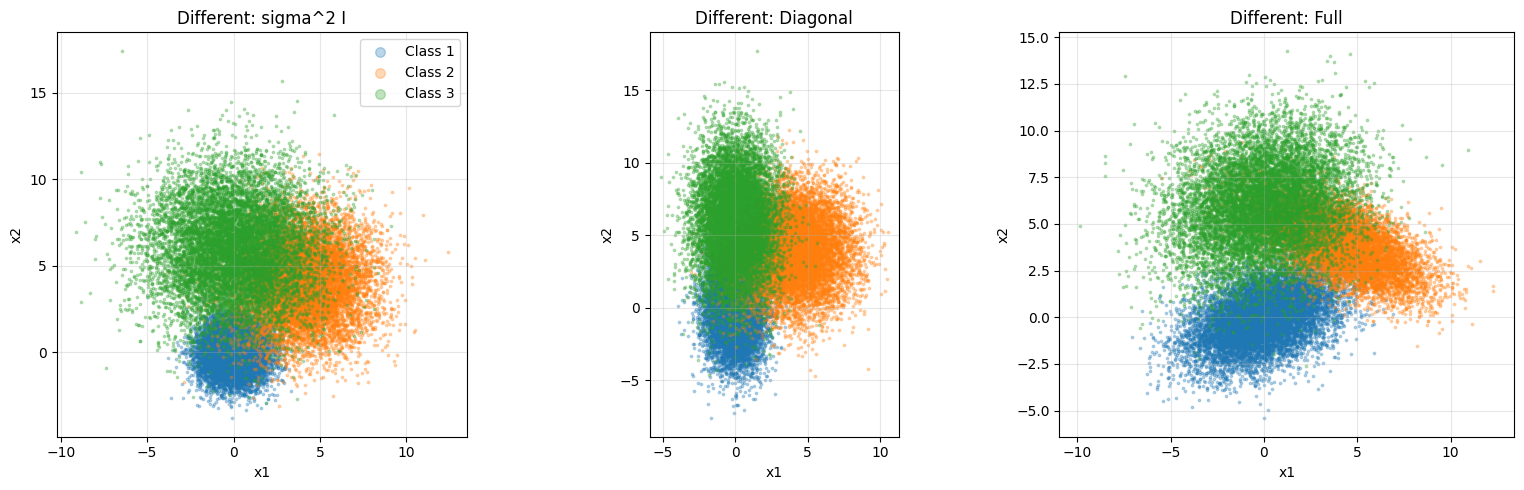

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sets = [("sigma^2 I", D1, D2, D3),
        ("Diagonal",  E1, E2, E3),
        ("Full",      F1, F2, F3)]

for ax, (title, P1, P2, P3) in zip(axes, sets):
    ax.scatter(P1[:, 0], P1[:, 1], s=3, alpha=0.3, label="Class 1")
    ax.scatter(P2[:, 0], P2[:, 1], s=3, alpha=0.3, label="Class 2")
    ax.scatter(P3[:, 0], P3[:, 1], s=3, alpha=0.3, label="Class 3")
    ax.set_title(f"Different: {title}")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal"); ax.grid(alpha=0.3)

axes[0].legend(markerscale=4)
plt.tight_layout()
plt.show()


In [54]:
# split: 80% train (8000), 20% test (2000) per class

F1_train, F1_test = F1[:8000], F1[8000:]
F2_train, F2_test = F2[:8000], F2[8000:]
F3_train, F3_test = F3[:8000], F3[8000:]

print(F1_train.shape, F1_test.shape)

(8000, 2) (2000, 2)


In [55]:
def mle(X):
    n = len(X)
    mu_hat = np.array([np.sum(X[:, 0]) / n,
                       np.sum(X[:, 1]) / n])
    d1 = X[:, 0] - mu_hat[0]
    d2 = X[:, 1] - mu_hat[1]
    S11 = np.sum(d1 * d1) / n
    S12 = np.sum(d1 * d2) / n
    S22 = np.sum(d2 * d2) / n
    return mu_hat, np.array([[S11, S12], [S12, S22]])

mu1_hat, Sigma1_hat = mle(F1_train)
mu2_hat, Sigma2_hat = mle(F2_train)
mu3_hat, Sigma3_hat = mle(F3_train)

for i, (m, S) in enumerate([(mu1_hat, Sigma1_hat),
                            (mu2_hat, Sigma2_hat),
                            (mu3_hat, Sigma3_hat)], start=1):
    print(f"Class {i}  mu_hat = {np.round(m, 3)}")
    print(np.round(S, 3))

Class 1  mu_hat = [-0.012 -0.   ]
[[4.084 1.194]
 [1.194 1.996]]
Class 2  mu_hat = [3.972 4.024]
[[ 5.058 -1.944]
 [-1.944  2.008]]
Class 3  mu_hat = [-0.024  5.98 ]
[[5.959 0.972]
 [0.972 4.921]]


In [56]:
datasets = {
    "Same, sigma^2 I": [A1, A2, A3],
    "Same, diagonal":  [B1, B2, B3],
    "Same, full":      [C1, C2, C3],
    "Diff, sigma^2 I": [D1, D2, D3],
    "Diff, diagonal":  [E1, E2, E3],
    "Diff, full":      [F1, F2, F3],
}

train, test, params = {}, {}, {}

for name, classes in datasets.items():
    train[name]  = [X[:8000] for X in classes]
    test[name]   = [X[8000:] for X in classes]
    params[name] = [mle(X) for X in train[name]]

    print("\n" + name)
    for i in range(3):
        mu_hat, Sigma_hat = params[name][i]
        print(f"  Class {i+1}  mu_hat = {np.round(mu_hat, 3)}")
        print(np.round(Sigma_hat, 3))


Same, sigma^2 I
  Class 1  mu_hat = [ 0.017 -0.014]
[[ 3.044 -0.006]
 [-0.006  3.009]]
  Class 2  mu_hat = [3.994 3.957]
[[3.091e+00 3.000e-03]
 [3.000e-03 3.022e+00]]
  Class 3  mu_hat = [-0.021  6.   ]
[[ 3.013 -0.006]
 [-0.006  3.023]]

Same, diagonal
  Class 1  mu_hat = [-0.005  0.005]
[[6.009 0.02 ]
 [0.02  4.091]]
  Class 2  mu_hat = [3.975 3.999]
[[6.041 0.064]
 [0.064 3.941]]
  Class 3  mu_hat = [0.024 6.055]
[[ 5.925 -0.014]
 [-0.014  3.995]]

Same, full
  Class 1  mu_hat = [-0.006 -0.004]
[[5.111 1.519]
 [1.519 1.965]]
  Class 2  mu_hat = [4.005 4.004]
[[4.917 1.465]
 [1.465 1.964]]
  Class 3  mu_hat = [-0.02   6.004]
[[5.031 1.508]
 [1.508 1.967]]

Diff, sigma^2 I
  Class 1  mu_hat = [ 0.005 -0.001]
[[0.999 0.017]
 [0.017 1.028]]
  Class 2  mu_hat = [3.991 4.043]
[[4.005 0.107]
 [0.107 4.06 ]]
  Class 3  mu_hat = [-0.01   5.985]
[[ 5.912 -0.04 ]
 [-0.04   5.956]]

Diff, diagonal
  Class 1  mu_hat = [ 0.003 -0.014]
[[1.031 0.005]
 [0.005 3.929]]
  Class 2  mu_hat = [3.992 4.

In [57]:
def discriminant_score(X, mu_hat, Sigma_hat):
    a = Sigma_hat[0, 0]
    b = Sigma_hat[0, 1]
    d = Sigma_hat[1, 1]

    det = a * d - b * b
    inv11 = d / det
    inv12 = -b / det
    inv22 = a / det

    u = X[:, 0] - mu_hat[0]
    v = X[:, 1] - mu_hat[1]

    maha2 = inv11 * u * u + 2 * inv12 * u * v + inv22 * v * v

    return -0.5 * maha2 - 0.5 * np.log(det)

In [58]:
predictions = {}

for name in datasets:
    X_test = np.vstack(test[name])
    y_true = np.concatenate([np.full(2000, 0),
                             np.full(2000, 1),
                             np.full(2000, 2)])

    g1 = discriminant_score(X_test, *params[name][0])
    g2 = discriminant_score(X_test, *params[name][1])
    g3 = discriminant_score(X_test, *params[name][2])

    scores = np.column_stack((g1, g2, g3))
    y_pred = np.argmax(scores, axis=1)

    predictions[name] = (X_test, y_true, y_pred)

    correct = np.sum(y_pred == y_true)
    print(f"{name:18s} correct: {correct} / {len(y_true)}")

Same, sigma^2 I    correct: 5323 / 6000
Same, diagonal     correct: 4840 / 6000
Same, full         correct: 5472 / 6000
Diff, sigma^2 I    correct: 5278 / 6000
Diff, diagonal     correct: 5176 / 6000
Diff, full         correct: 5246 / 6000


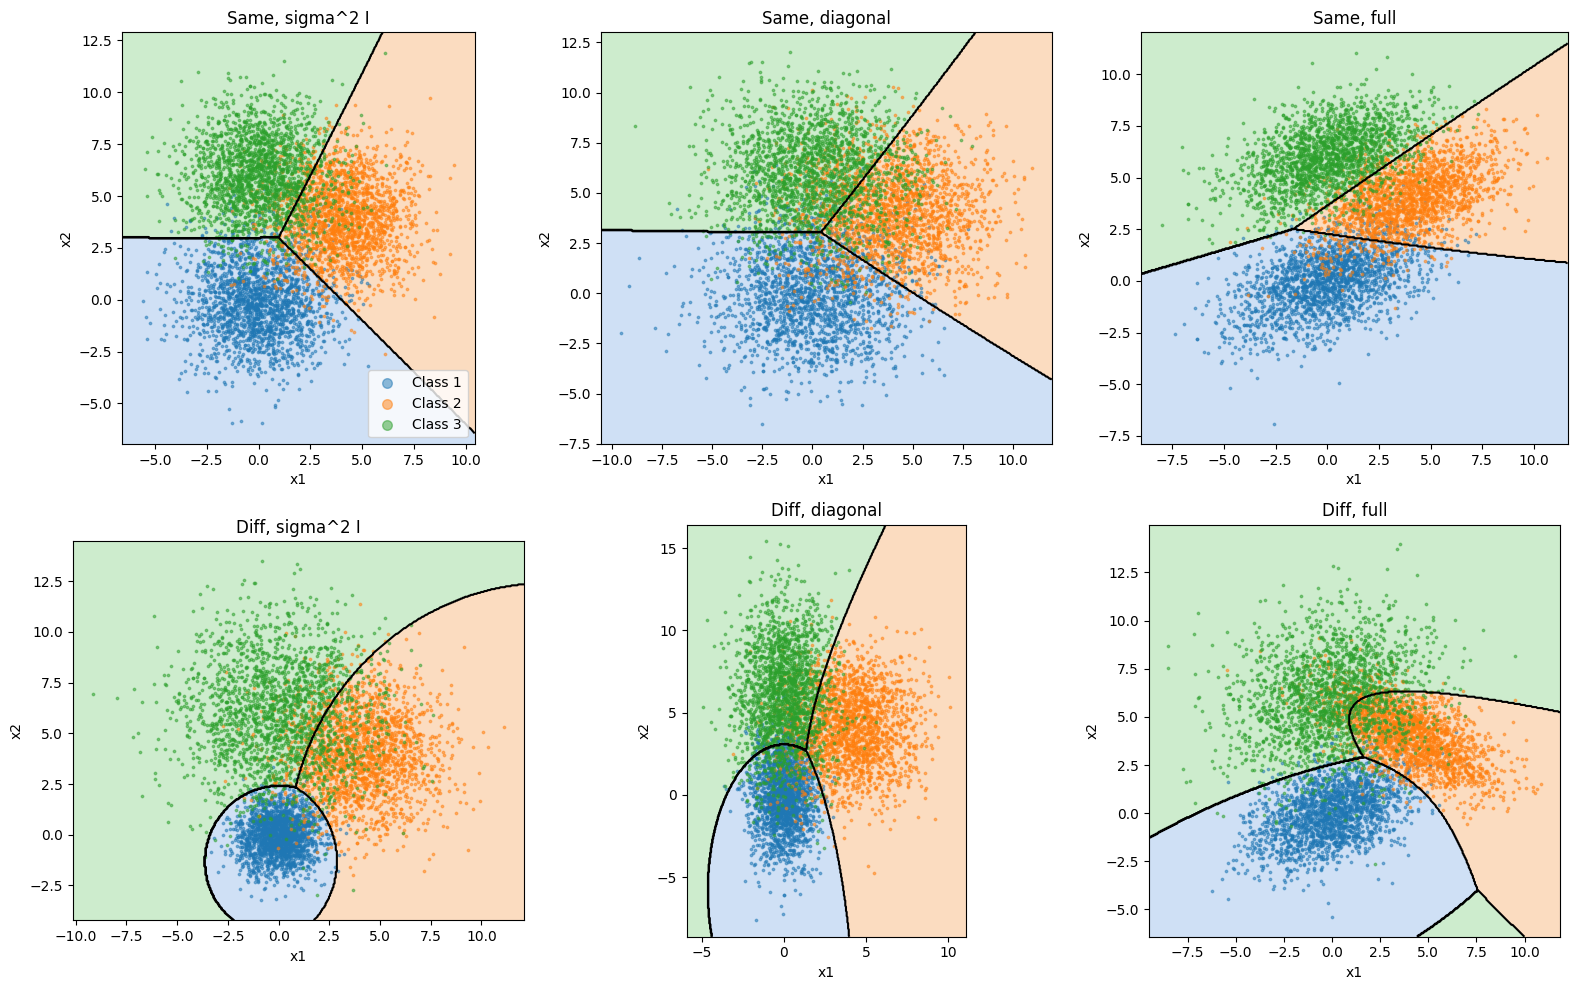

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
region_colors = plt.matplotlib.colors.ListedColormap(["#cfe0f5", "#fbdcc0", "#cdeccd"])
point_colors = ["tab:blue", "tab:orange", "tab:green"]

for ax, name in zip(axes.ravel(), datasets):
    X_test, y_true, y_pred = predictions[name]

    gx = np.linspace(X_test[:, 0].min() - 1, X_test[:, 0].max() + 1, 400)
    gy = np.linspace(X_test[:, 1].min() - 1, X_test[:, 1].max() + 1, 400)
    GX, GY = np.meshgrid(gx, gy)
    grid = np.column_stack((GX.ravel(), GY.ravel()))

    s1 = discriminant_score(grid, *params[name][0])
    s2 = discriminant_score(grid, *params[name][1])
    s3 = discriminant_score(grid, *params[name][2])
    Z = np.argmax(np.column_stack((s1, s2, s3)), axis=1).reshape(GX.shape)

    ax.contourf(GX, GY, Z, levels=[-0.5, 0.5, 1.5, 2.5], cmap=region_colors)
    ax.contour(GX, GY, Z, levels=[0.5, 1.5], colors="black", linewidths=1.5)

    for c in range(3):
        pts = X_test[y_true == c]
        ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.5,
                   color=point_colors[c], label=f"Class {c+1}")

    ax.set_title(name)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal")

axes[0, 0].legend(markerscale=4, loc="lower right")
plt.tight_layout()
plt.show()


PART 2

In [60]:
import numpy as np
import matplotlib.pyplot as plt

train_file = "trian.txt"
dev_file = "dev.txt"

train_data = np.loadtxt(train_file, delimiter=",")
dev_data = np.loadtxt(dev_file, delimiter=",")

print(train_data.shape)
print(dev_data.shape)


(1050, 3)
(300, 3)


In [61]:
X_train = train_data[:, :2]
y_train = train_data[:, 2].astype(int)

X_dev = dev_data[:, :2]
y_dev = dev_data[:, 2].astype(int)

classes = np.unique(y_train)

print("Classes:", classes)
print("Train shape:", X_train.shape)
print("Dev shape:", X_dev.shape)


Classes: [1 2 3]
Train shape: (1050, 2)
Dev shape: (300, 2)


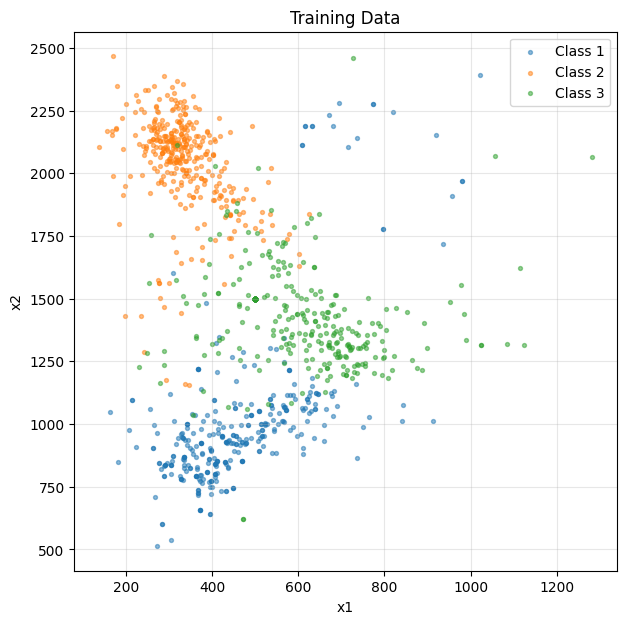

In [62]:
plt.figure(figsize=(7, 7))

for c in classes:
    pts = X_train[y_train == c]
    plt.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.5, label=f"Class {c}")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Training Data")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [63]:
def mle(X):
    n = len(X)

    mu_hat = np.array([
        np.sum(X[:, 0]) / n,
        np.sum(X[:, 1]) / n
    ])

    d1 = X[:, 0] - mu_hat[0]
    d2 = X[:, 1] - mu_hat[1]

    S11 = np.sum(d1 * d1) / n
    S12 = np.sum(d1 * d2) / n
    S22 = np.sum(d2 * d2) / n

    return mu_hat, np.array([
        [S11, S12],
        [S12, S22]
    ])

In [64]:
params = {}

for c in classes:
    X_class = X_train[y_train == c]
    params[c] = mle(X_class)

    mu_hat, Sigma_hat = params[c]

    print(f"\nClass {c}")
    print("mu_hat =", np.round(mu_hat, 3))
    print("Sigma_hat =")
    print(np.round(Sigma_hat, 3))


Class 1
mu_hat = [ 467.883 1033.395]
Sigma_hat =
[[ 20570.71   29323.54 ]
 [ 29323.54  107046.985]]

Class 2
mu_hat = [ 334.052 2039.489]
Sigma_hat =
[[ 6144.701 -5596.692]
 [-5596.692 39443.48 ]]

Class 3
mu_hat = [ 593.408 1436.551]
Sigma_hat =
[[22230.86 -5172.7 ]
 [-5172.7  35192.87]]


In [65]:
def discriminant_score(X, mu_hat, Sigma_hat):
    a = Sigma_hat[0, 0]
    b = Sigma_hat[0, 1]
    d = Sigma_hat[1, 1]

    det = a * d - b * b

    inv11 = d / det
    inv12 = -b / det
    inv22 = a / det

    u = X[:, 0] - mu_hat[0]
    v = X[:, 1] - mu_hat[1]

    maha2 = (
        inv11 * u * u
        + 2 * inv12 * u * v
        + inv22 * v * v
    )

    return -0.5 * maha2 - 0.5 * np.log(det)

In [66]:
scores = []

for c in classes:
    mu_hat, Sigma_hat = params[c]

    score = discriminant_score(
        X_dev,
        mu_hat,
        Sigma_hat
    )

    scores.append(score)

scores = np.column_stack(scores)

predicted_indices = np.argmax(scores, axis=1)

y_pred = classes[predicted_indices]

correct = np.sum(y_pred == y_dev)
accuracy = correct / len(y_dev)

print("\nCorrect:", correct)
print("Total:", len(y_dev))
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)


Correct: 267
Total: 300
Accuracy: 0.89
Accuracy (%): 89.0


In [67]:
confusion = np.zeros((len(classes), len(classes)), dtype=int)

for actual, predicted in zip(y_dev, y_pred):
    i = np.where(classes == actual)[0][0]
    j = np.where(classes == predicted)[0][0]
    confusion[i, j] += 1

print("\nConfusion Matrix")
print(confusion)


Confusion Matrix
[[88  0 12]
 [ 1 93  6]
 [ 5  9 86]]


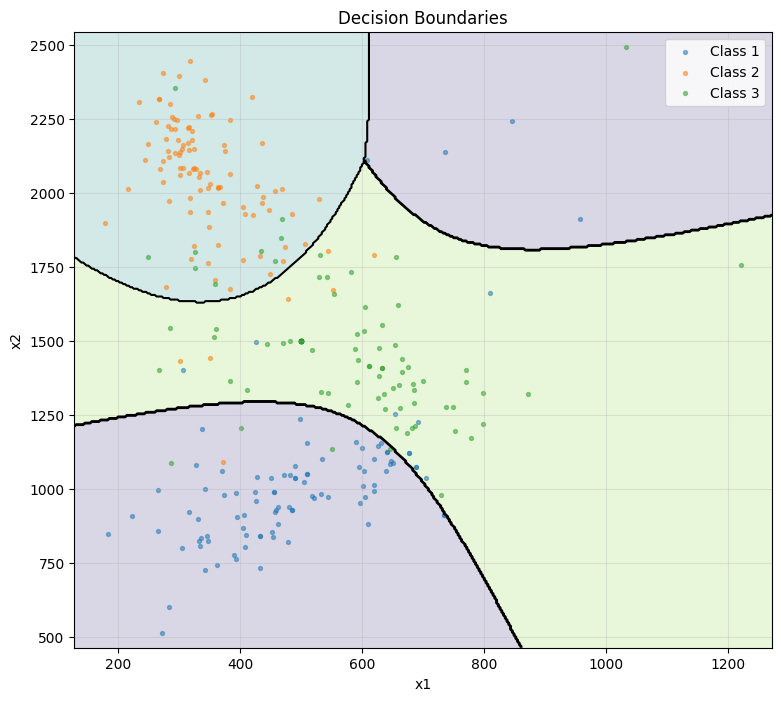

In [68]:
gx = np.linspace(
    X_dev[:, 0].min() - 50,
    X_dev[:, 0].max() + 50,
    400
)

gy = np.linspace(
    X_dev[:, 1].min() - 50,
    X_dev[:, 1].max() + 50,
    400
)

GX, GY = np.meshgrid(gx, gy)

grid = np.column_stack((
    GX.ravel(),
    GY.ravel()
))

grid_scores = []

for c in classes:
    mu_hat, Sigma_hat = params[c]

    score = discriminant_score(
        grid,
        mu_hat,
        Sigma_hat
    )

    grid_scores.append(score)

grid_scores = np.column_stack(grid_scores)

Z = np.argmax(
    grid_scores,
    axis=1
).reshape(GX.shape)

plt.figure(figsize=(9, 8))

plt.contourf(
    GX,
    GY,
    Z,
    levels=np.arange(len(classes) + 1) - 0.5,
    alpha=0.2
)

plt.contour(
    GX,
    GY,
    Z,
    levels=np.arange(len(classes) - 1) + 0.5,
    colors="black",
    linewidths=1.5
)

for c in classes:
    pts = X_dev[y_dev == c]

    plt.scatter(
        pts[:, 0],
        pts[:, 1],
        s=8,
        alpha=0.5,
        label=f"Class {c}"
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundaries")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

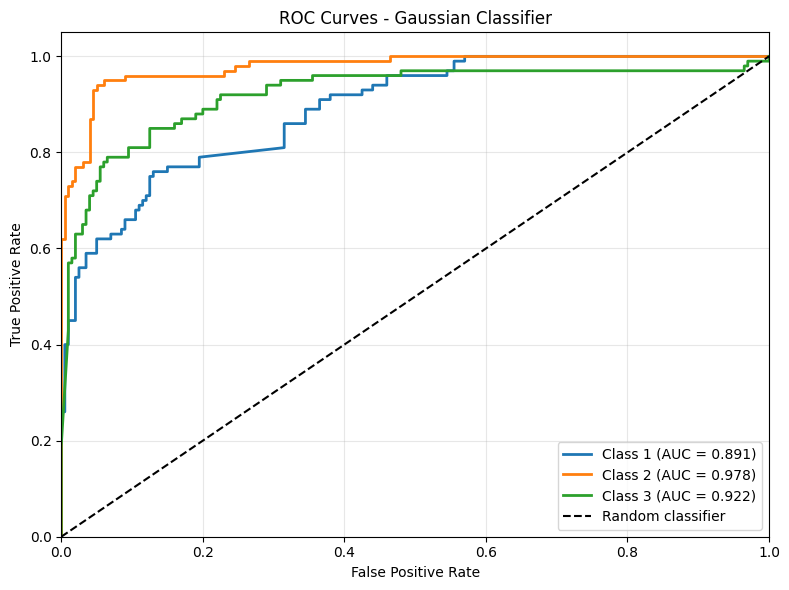

In [69]:

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_dev_binary = label_binarize(y_dev, classes=classes)

plt.figure(figsize=(8, 6))

for i, c in enumerate(classes):
    y_binary = y_dev_binary[:, i]

    class_scores = scores[:, i]

    fpr, tpr, thresholds = roc_curve(
        y_binary,
        class_scores
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"Class {c} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Gaussian Classifier")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()